In [1]:
import os
import numpy as np
import brian2 as br
br.prefs.codegen.target = 'numpy' # configure brian2 to use the Python fallback
import matplotlib.pyplot as plt

In [2]:
dtime = 0.1 * br.ms
duration = 1000 * br.ms
br.start_scope()
br.defaultclock.dt = dtime

In [21]:
#Model Parameters
#Neuron Membrane
C = 3.3e-7 * br.farad        # membrane capacitance. (10 ufarad is Cm, actual value)
ga = 1/(2.2e3)  * br.siemens     # axon hillock conductance (49ohm is Ra, 2 is a fitting coef)
gg = 1/(680e3) * br.siemens     # membrane leak (100kohm is Rg, actual value)

#Thyristor
IT = 4.95e-6 * br.amp         # thyristor gate threshold current (this is a parameter that needs to be fit for each thyristor)
VT = IT / gg               # threshold voltage
IH = 105e-6 * br.amp       # thyristor holding current (this is a parameter that needs to be fit for each thyristor) 105e-6 *
Vr = IH / ga               # reset voltage
V0 = 1e-4 * br.volt        # thyristor sensitivity (just a small value, not critical)
tn = 60 * br.ms            # thyristor gate time scale, ie PO118 datasheet, should be around 50ns
Id = 200e-6 * br.amp         # current delta sent on spike. (model parameter)


'''
C = 10e-6 * br.farad        # membrane capacitance. (10 ufarad is Cm, actual value)
ga = 1/(2*49)  * br.siemens     # axon hillock conductance (49ohm is Ra, 2 is a fitting coef)
gg = 1/(100.e3) * br.siemens     # membrane leak (100kohm is Rg, actual value)
IT = 2.6e-6 * br.amp         # thyristor gate threshold current (this is a parameter that needs to be fit for each thyristor)
VT = IT / gg               # threshold voltage
IH = 120e-6 * br.amp       # thyristor holding current (this is a parameter that needs to be fit for each thyristor)
Vr = IH / ga               # reset voltage
V0 = 1e-3 * br.volt        # thyristor sensitivity (just a small value, not critical)
Id = 200e-6 * br.amp         # current delta sent on spike. (model parameter)
tau = 60 * br.ms           # synapse time constant. (model parameter)
'''

'\nC = 10e-6 * br.farad        # membrane capacitance. (10 ufarad is Cm, actual value)\nga = 1/(2*49)  * br.siemens     # axon hillock conductance (49ohm is Ra, 2 is a fitting coef)\ngg = 1/(100.e3) * br.siemens     # membrane leak (100kohm is Rg, actual value)\nIT = 2.6e-6 * br.amp         # thyristor gate threshold current (this is a parameter that needs to be fit for each thyristor)\nVT = IT / gg               # threshold voltage\nIH = 120e-6 * br.amp       # thyristor holding current (this is a parameter that needs to be fit for each thyristor)\nVr = IH / ga               # reset voltage\nV0 = 1e-3 * br.volt        # thyristor sensitivity (just a small value, not critical)\nId = 200e-6 * br.amp         # current delta sent on spike. (model parameter)\ntau = 60 * br.ms           # synapse time constant. (model parameter)\n'

In [23]:
eqs = '''
    dV/dt = (-(ga*n + gg) * V + I0 + Ib) / C : volt
    dv_dt = (-(ga*n + gg) * V + I0 + Ib) / C : volt/second # copy of value of derivative of V, used in calc_n()
    dn/dt = (calc_n(V,dv_dt) - n) / (0.2*ms) : 1
    dIa/dt = (-Ia + Iin) / tau : amp
    dIb/dt = (-Ib + Ia) / tau : amp
    I0 : amp # constant input current
    Vp = (I0 - C*dv_dt - gg*V) / (ga) : volt # action potential. it is the current along ga divided by ga
    Iin : amp # total input received by other neurons
    '''

Define function to evaluate dn/dt accounting for hysteresis

In [24]:
@br.check_units(V=br.volt, dV_dt=br.volt/br.second, result=1)
def calc_n(V,dV_dt):
    v1 = (VT - V) / V0
    v2 = (Vr - V) / V0

    term1 = br.zeros(v1.shape)
    term1[v1<10] = 1.0 / (1.0 + br.exp(v1[v1<10])) # check size of v1 to avoid numerical errors
    term1 = term1 * (1.0 + br.sign(dV_dt)) / 2.0 # set to zero if dV_dt < 0

    term2 = br.zeros(v2.shape)
    term2[v2<10] = 1.0 / (1.0 + br.exp(v2[v2<10])) # to avoid numerical errors
    term2 = term2 * (1.0 - br.sign(dV_dt)) / 2.0 # set to zero if dV_dt > 0

    if not dV_dt.all() :
        print('Warning: derivative of V is zero, integration errors might occur.')

    return term1 + term2

In [25]:
@br.check_units(Vp=br.volt, result=1)
def calc_ns(Vp):

    ns = 1.0
    if Vp < 0.05 * br.volt :
        ns = 0.0
    return ns

Define neuron population

In [26]:
N = 2 # number of neurons
#neurons = br.NeuronGroup(N,eqs,threshold='Vp>0.7*volt',reset='',method='heun')
neurons = br.NeuronGroup(N,eqs,method='euler')
# initial conditions
neurons.V = 0 * br.volt
neurons.n = 0
neurons.Ia = 0 * br.amp
neurons.Ib = 0 * br.amp
# parameter values
neurons.I0[0] = 10e-6 * br.amp # 92.4e-6 * br.amp
neurons.I0[1] = 1e-6 * br.amp
neurons.Iin = 0


#neurons.Vap = 1 * br.volt



Define connections

In [27]:
#conn = br.Synapses(neurons,neurons,'Iin_post =  n_pre*Id : amp (summed)')
conn = br.Synapses(neurons,neurons,'Iin_post =  calc_ns(Vp_pre)*Id : amp (summed)')
conn.connect(i=0,j=1)

Define monitors

In [28]:
activity = br.StateMonitor(neurons,['V','n','Ia','Ib', 'Vp','Iin'],record=True)

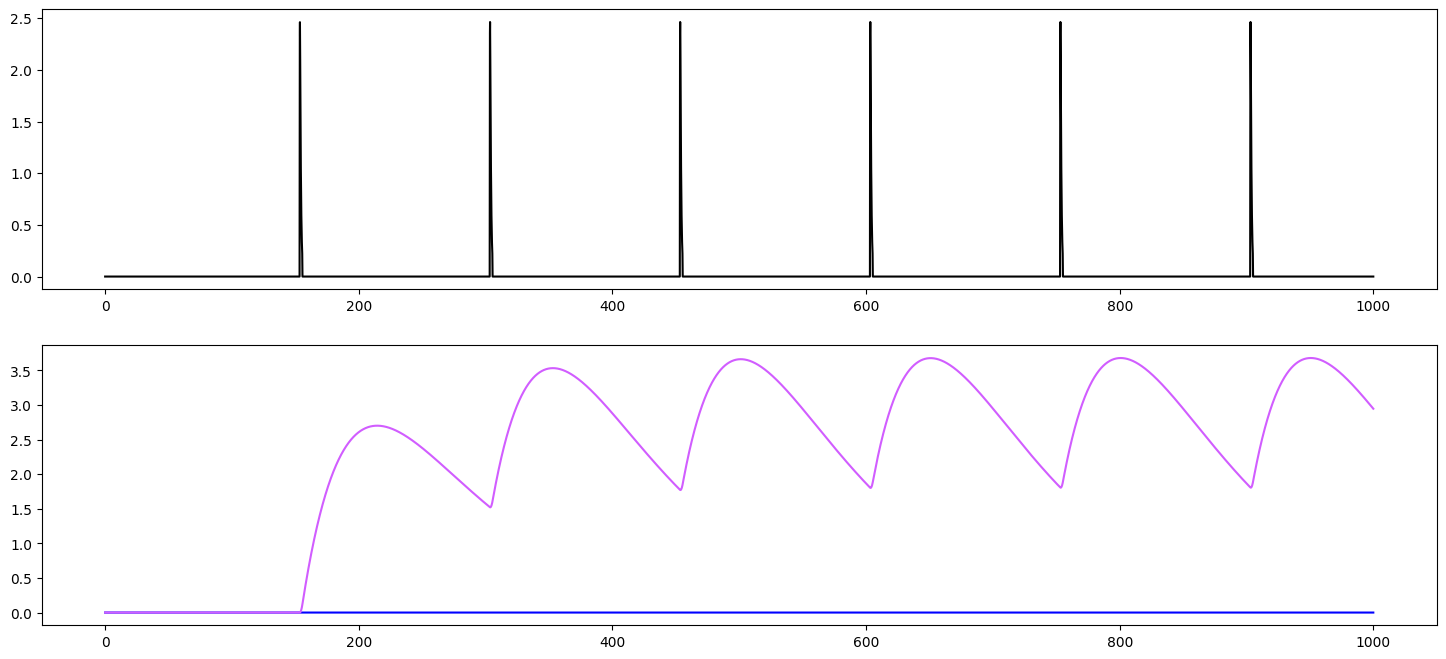

In [29]:
tau = tn  # eqs uses tau; reuse the existing time constant
Id = 200e-6 * br.amp
br.run(duration)
i = 0
# just for checking Vap
caca = activity.Vp[i] # get the monitered value

Vap_list = [] # an empty list to story Vap

# a loop to process Vp (in caca) one by one, because our calc_ns() function can only do one value, instead of an array
for Vp_item in caca: # take one value of Vp from caca
  ns_item = calc_ns(Vp_item) # calculate corresponding ns
  Vap_item = Vp_item * ns_item # caculate corresponding Vap
  Vap_list.append(Vap_item) # store Vap into the empty list

Vap = np.array(Vap_list) # change the list into array type


# plot Vap and Ib (synaptic current)
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(18,8))
ax1.plot(activity.t/br.ms,Vap,label='Vap',color='black',zorder=4)
ax2.plot(activity.t/br.ms,activity.Ib[0]/br.uamp,label='Ib',color='blue')
ax2.plot(activity.t/br.ms,activity.Ib[1]/br.uamp,label='Ib',color='#d15dffff')

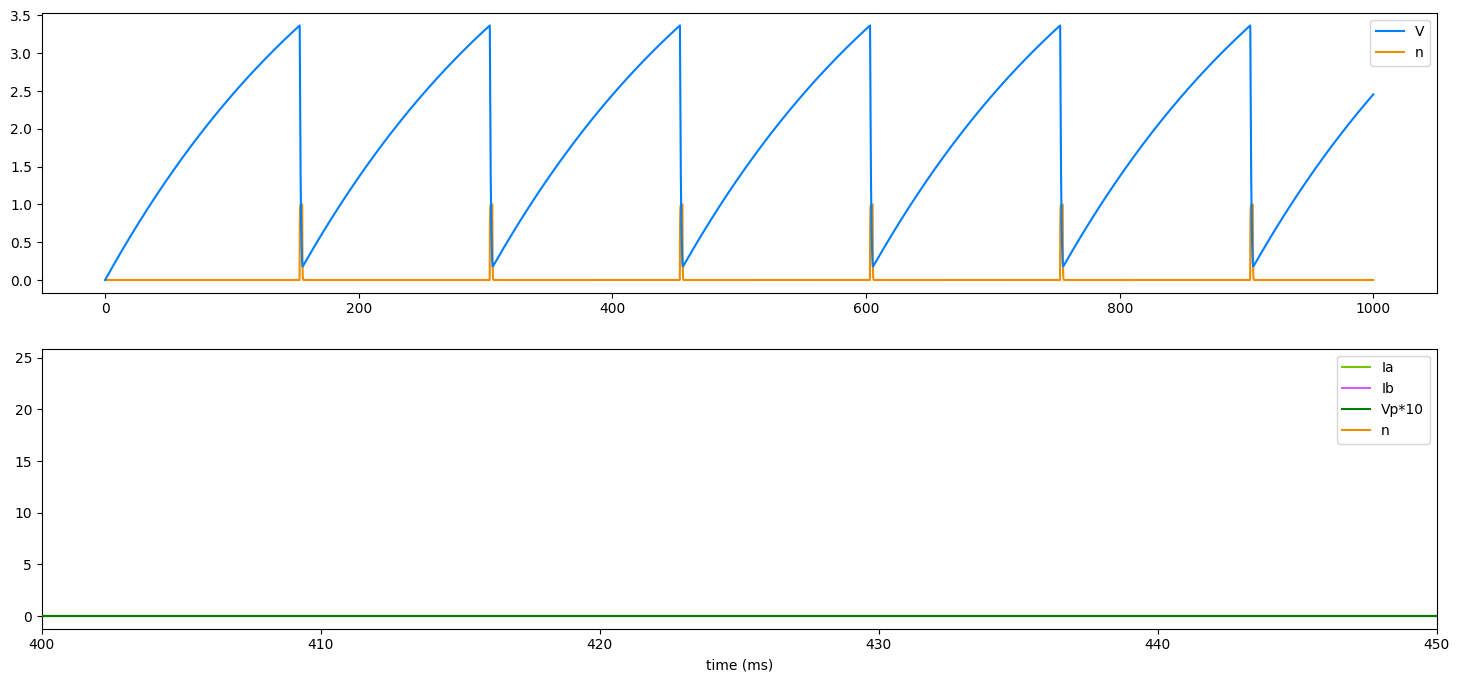

In [30]:
# first neuron, receiving no input
i = 0
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(18,8))
ax1.plot(activity.t/br.ms,activity.V[i]/br.volt,label='V',color='#007efbff',zorder=5)
#caca=activity.Vp[i]
#pis=calc_ns(caca)*caca
#ax1.plot(activity.t/br.ms,caca/br.volt,label='Vap',color='black',zorder=4)
ax1.plot(activity.t/br.ms,activity.n[i],label='n',color='#ef8d00ff',zorder=4)
ax2.plot(activity.t/br.ms,activity.Ia[i]/br.amp,label='Ia',color='#75c600ff',zorder=3)
ax2.plot(activity.t/br.ms,activity.Ib[i]/br.amp,label='Ib',color='#d15dffff',zorder=2)
ax2.plot(activity.t/br.ms,activity.Vp[i]*10/br.volt,label='Vp*10',color='green',zorder=6)
ax2.plot(activity.t/br.ms,activity.n[i],label='n',color='#ef8d00ff',zorder=4)
ax2.set_xlabel('time (ms)'); ax1.legend(); ax2.legend(); ax2.set_xlim(400,450);

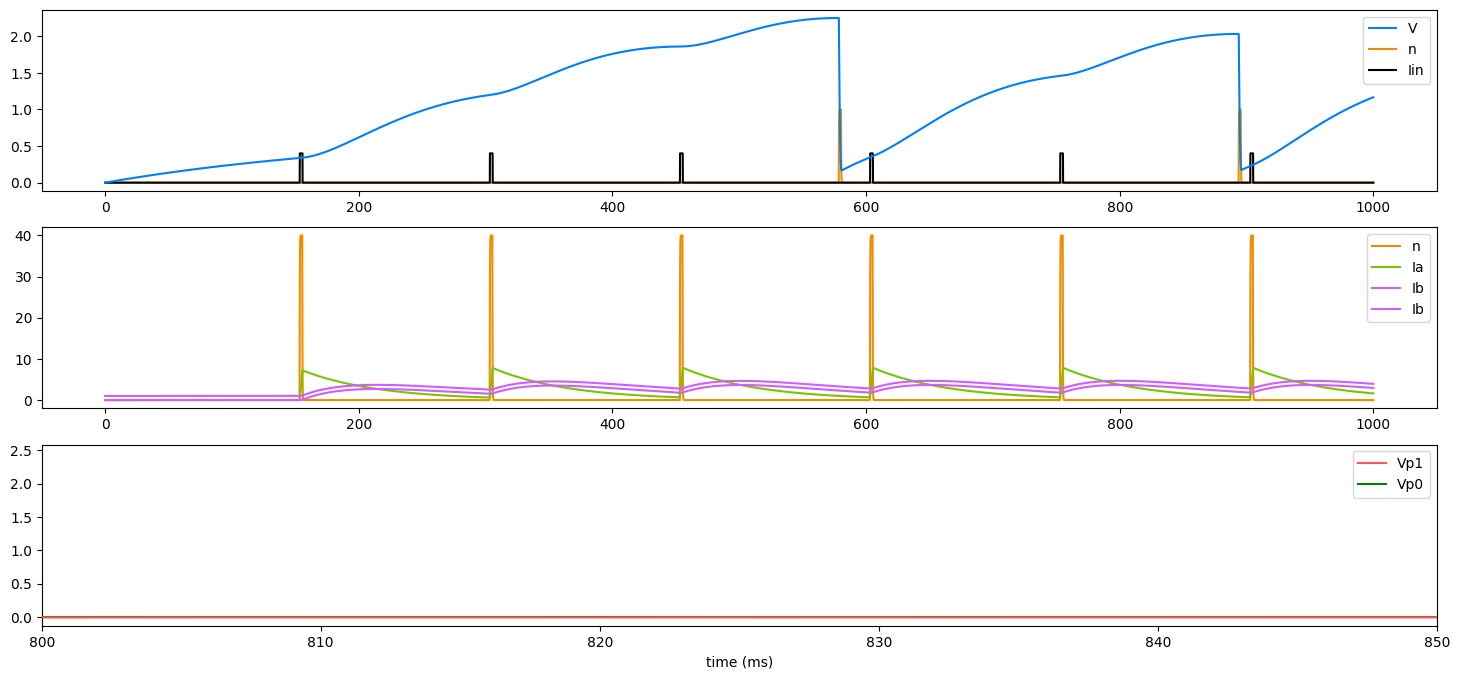

In [31]:
# target neuron, receiving input from first
i = 1
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(18,8))
ax1.plot(activity.t/br.ms,activity.V[i]/br.volt,label='V',color='#007efbff',zorder=2)
ax1.plot(activity.t/br.ms,activity.n[i],label='n',color='#ef8d00ff',zorder=1)
ax1.plot(activity.t/br.ms,activity.Iin[i]*2000,label='Iin',color='black',zorder=1)
ax2.plot(activity.t/br.ms,activity.n[0]*40,label='n',color='#ef8d00ff',zorder=1)
ax2.plot(activity.t/br.ms,activity.Ia[i]/br.uamp,label='Ia',color='#75c600ff')
ax2.plot(activity.t/br.ms,activity.Ib[i]/br.uamp,label='Ib',color='#d15dffff')

ax2.plot(activity.t/br.ms,(neurons.I0[i]+activity.Ib[i])/br.uamp,label='Ib',color='#d15dffff')

ax3.plot(activity.t/br.ms,activity.Vp[i]/br.volt,label='Vp1',color='#ff5656ff',zorder=3)
ax3.plot(activity.t/br.ms,activity.Vp[0]/br.volt,label='Vp0',color='green',zorder=2)
ax3.set_xlabel('time (ms)'); ax1.legend(); ax2.legend(); ax3.legend();  ax3.set_xlim(800,850);

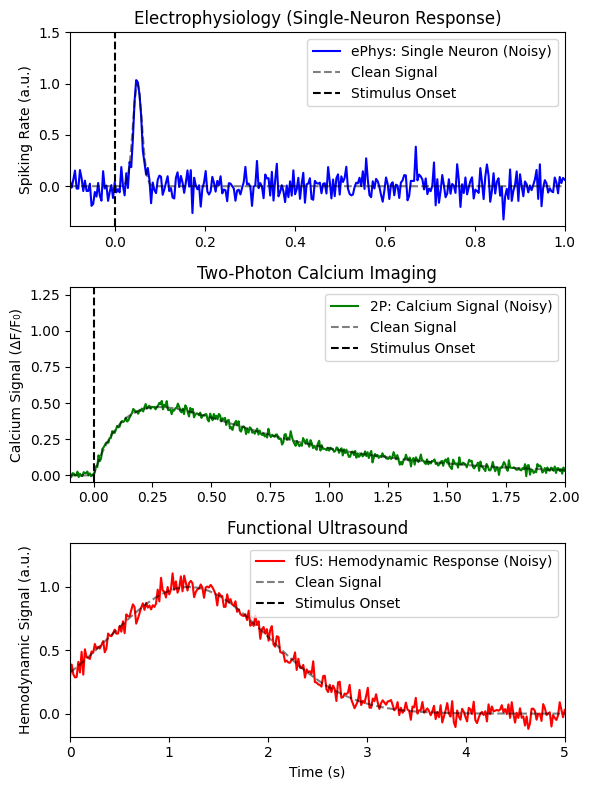

In [ ]:
# For reproducibility of random noise:
np.random.seed(42)

# ------------------------------------------------------------------------
# 1) Electrophysiology: Single-neuron spiking
#    Fast, sharp peak shortly after stimulus onset (t=0), plus white noise
# ------------------------------------------------------------------------
ephys_time = np.linspace(-0.1, 1.0, 300)  # from -100 ms to 1 s
# Create a synthetic “spike-like” response around t=0.05
# We'll use a Gaussian as a stand-in for the spike burst shape
peak_center_ephys = 0.05
peak_amplitude_ephys = 1.0
peak_width_ephys = 0.01

# Ideal (noise-free) response:
ephys_response_clean = peak_amplitude_ephys * np.exp(
    -0.5 * ((ephys_time - peak_center_ephys) / peak_width_ephys) ** 2
)

# Add white noise:
noise_amplitude_ephys = 0.1
ephys_response_noisy = ephys_response_clean + noise_amplitude_ephys * np.random.randn(len(ephys_time))

# ------------------------------------------------------------------------
# 2) Two-photon Calcium Imaging: Calcium signal from a single neuron
#    Slower rise and decay, plus white noise
# ------------------------------------------------------------------------
twoP_time = np.linspace(-0.1, 2.0, 400)  # from -100 ms to 2 s

# Synthetic calcium response: a smooth rise after stimulus onset (near t=0)
# We'll combine a rising exponential and a decay
tau_rise = 0.2   # ~200 ms rise
tau_decay = 0.6  # ~600 ms decay
amp_2p = 1.0

def calcium_response(t, t0=0, amp=1, tau_r=0.2, tau_d=0.6):
    """ Roughly: 0 for t < t0, then a rise-then-decay envelope for t >= t0. """
    resp = np.zeros_like(t)
    t_idx = t >= t0
    t_shifted = t[t_idx] - t0
    # Simple difference-of-exponentials shape
    resp[t_idx] = amp * (1 - np.exp(-t_shifted/tau_r)) * np.exp(-t_shifted/tau_d)
    return resp

twoP_response_clean = calcium_response(twoP_time, t0=0, amp=amp_2p,
                                       tau_r=tau_rise, tau_d=tau_decay)

# Add white noise:
noise_amplitude_2P = 0.02
twoP_response_noisy = twoP_response_clean + noise_amplitude_2P * np.random.randn(len(twoP_time))

# ------------------------------------------------------------------------
# 3) Functional Ultrasound (fUS): Hemodynamic response in a region of interest
#    Slower, broader peak, plus white noise
# ------------------------------------------------------------------------
fUS_time = np.linspace(0, 5.0, 300)  # from 0 to 5 s

# Synthetic hemodynamic-like response: delayed peak ~1–2 s, slow return
peak_center_fUS = 1.2
peak_width_fUS = 0.8
peak_amplitude_fUS = 1.0

def hemodynamic_response(t, center=1.2, width=0.8, amp=1.0):
    return amp * np.exp(-0.5 * ((t - center) / width) ** 2)

fUS_response_clean = hemodynamic_response(fUS_time, center=peak_center_fUS,
                                          width=peak_width_fUS, amp=peak_amplitude_fUS)

# Add white noise:
noise_amplitude_fUS = 0.05
fUS_response_noisy = fUS_response_clean + noise_amplitude_fUS * np.random.randn(len(fUS_time))

# ------------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=False)

# 1) ePhys
ax = axes[0]
ax.plot(ephys_time, ephys_response_noisy, color='b', label='ePhys: Single Neuron (Noisy)')
ax.plot(ephys_time, ephys_response_clean, color='k', alpha=0.5, linestyle='--', label='Clean Signal')
ax.axvline(0, color='k', linestyle='--', label='Stimulus Onset')
ax.set_xlim([-0.1, 1.0])
ax.set_ylim([None, 1.2 + noise_amplitude_ephys*3])
ax.set_ylabel('Spiking Rate (a.u.)')
ax.set_title('Electrophysiology (Single-Neuron Response)')
ax.legend(loc='upper right')

# 2) 2P Imaging
ax = axes[1]
ax.plot(twoP_time, twoP_response_noisy, color='g', label='2P: Calcium Signal (Noisy)')
ax.plot(twoP_time, twoP_response_clean, color='k', alpha=0.5, linestyle='--', label='Clean Signal')
ax.axvline(0, color='k', linestyle='--', label='Stimulus Onset')
ax.set_xlim([-0.1, 2.0])
ax.set_ylim([None, 1.2 + noise_amplitude_2P*5])
ax.set_ylabel('Calcium Signal (ΔF/F₀)')
ax.set_title('Two-Photon Calcium Imaging')
ax.legend(loc='upper right')

# 3) fUS
ax = axes[2]
ax.plot(fUS_time, fUS_response_noisy, color='r', label='fUS: Hemodynamic Response (Noisy)')
ax.plot(fUS_time, fUS_response_clean, color='k', alpha=0.5, linestyle='--', label='Clean Signal')
ax.axvline(0, color='k', linestyle='--', label='Stimulus Onset')
ax.set_xlim([0, 5.0])
ax.set_ylim([None, 1.2 + noise_amplitude_fUS*3])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Hemodynamic Signal (a.u.)')
ax.set_title('Functional Ultrasound')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
